<a href="https://colab.research.google.com/github/Abhishek00809/Eco_Travel_Chatbot/blob/main/Eco_travel_chatbot_zibraan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!sudo apt-get update

!sudo apt-get install python3.8 python3.8-venv -y # Install the module needed to create virtual environments specifically for Python 3.8

!python3.8 -m venv /usr/local/rasa_venv #This command creates a virtual environment named rasa_venv in the /usr/local/ directory

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,764 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,258 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,046 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:13 https://pp

In [3]:
!source /usr/local/rasa_venv/bin/activate && \
  pip install --upgrade pip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1


In [4]:
!source /usr/local/rasa_venv/bin/activate && \
  pip install rasa==3.1.0 websockets==10.4 "sqlalchemy<2.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of sanic-cors to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tensorflow-text to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking

In [5]:
!pip install streamlit psycopg2-binary pyngrok --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 88.0 MB/s eta 0:00:00


In [6]:
%%writefile nlu.yml
version: "3.1"

nlu:

  # -------------------------
  # Lookup tables
  # -------------------------

  - lookup: origin_city
    examples: |
      - Berlin
      - Hamburg
      - Munich
      - Paris
      - London
      - Amsterdam
      - Vienna
      - Madrid
      - Rome
      - Lisbon
      - Prague
      - Copenhagen
      - Stockholm
      - Barcelona
      - Athens

  - lookup: destination_city
    examples: |
      - Berlin
      - Hamburg
      - Munich
      - Paris
      - London
      - Amsterdam
      - Vienna
      - Madrid
      - Rome
      - Lisbon
      - Prague
      - Copenhagen
      - Stockholm
      - Barcelona
      - Athens

  - lookup: sustainability_level
    examples: |
      - very eco-friendly
      - eco-friendly
      - low carbon
      - carbon neutral
      - sustainable
      - green
      - moderate
      - not important

  # -------------------------
  # Small talk / basic intents
  # -------------------------

  - intent: greet
    examples: |
      - hi
      - hello
      - hey
      - good morning
      - good evening
      - hi there
      - hey bot
      - hello there
      - hi, I need help planning a trip
      - hello, I want to book an eco-friendly holiday
      - hey, can you help me with my travel plans?

  - intent: goodbye
    examples: |
      - bye
      - goodbye
      - see you later
      - farewell
      - thanks, bye
      - talk to you later
      - that’s all, thanks
      - I’m done for now
      - ok, I will stop here
      - thank you, goodbye

  - intent: start
    examples: |
      - /start
      - start
      - let’s start
      - I want to start planning a trip
      - I want to plan an eco-friendly trip
      - help me plan a sustainable holiday

  - intent: affirm
    examples: |
      - yes
      - yeah
      - sure
      - of course
      - exactly
      - that’s right
      - correct

  - intent: deny
    examples: |
      - no
      - nope
      - not really
      - I don’t think so
      - that’s not right
      - wrong

  # -------------------------
  # Trip details: origin, destination, dates, budget
  # -------------------------

  - intent: provide_location
    examples: |
      - I want to travel from [Berlin](origin_city) to [Barcelona](destination_city)
      - I am going from [Paris](origin_city) to [Rome](destination_city)
      - My trip starts in [Berlin](origin_city) and ends in [Madrid](destination_city)
      - I will travel from [Hamburg](origin_city) to [Amsterdam](destination_city)
      - From [Munich](origin_city) to [Vienna](destination_city)
      - I live in [Berlin](origin_city) and want to visit [Prague](destination_city)
      - I’m flying from [London](origin_city) to [Lisbon](destination_city)
      - leaving [Berlin](origin_city) and going to [Athens](destination_city)
      - I want a route from [Copenhagen](origin_city) to [Stockholm](destination_city)
      - round trip from [Berlin](origin_city) to [Paris](destination_city)

  - intent: provide_origin_only
    examples: |
      - I am in [Berlin](origin_city)
      - I live in [Hamburg](origin_city)
      - I will leave from [Munich](origin_city)
      - my starting point is [Paris](origin_city)
      - I am currently in [London](origin_city)

  - intent: provide_destination_only
    examples: |
      - I want to go to [Barcelona](destination_city)
      - I would like to visit [Rome](destination_city)
      - my destination is [Vienna](destination_city)
      - I’m planning to travel to [Madrid](destination_city)
      - can you suggest an eco-friendly trip to [Lisbon](destination_city)

  - intent: trip_budget
    examples: |
      - My budget is [500](budget) euros
      - I have [300](budget) EUR
      - I can spend around [1000](budget)
      - I only have [150](budget) €
      - My maximum budget is [800](budget)
      - please keep it under [600](budget) euros
      - I want a low budget trip
      - I prefer a cheap trip
      - I am looking for an affordable holiday
      - please keep it as cheap as possible
      - money is not an issue, I can pay up to [2000](budget)

  - intent: trip_dates
    examples: |
      - I want to travel from [10 August](start_date) to [15 August](end_date)
      - I am planning a trip between [1 July](start_date) and [7 July](end_date)
      - I want to leave on [5 September](start_date)
      - I can travel next [weekend](start_date)
      - I want to go this [Friday](start_date)
      - my return date is [20 December](end_date)
      - I need a trip for [3 days](trip_duration)
      - I want to stay for [one week](trip_duration)

  # -------------------------
  # Sustainability and preferences
  # -------------------------

  - intent: express_sustainability_preference
    examples: |
      - I want a very eco-friendly trip
      - I prefer low carbon options
      - I want to minimise my carbon footprint
      - I only want sustainable transport
      - I prefer trains over planes
      - please avoid flights if possible
      - I want a carbon neutral holiday
      - I care a lot about the environment
      - sustainability is very important to me
      - I am okay with moderate emissions
      - I don’t really care about emissions

  - intent: ask_sustainable_options
    examples: |
      - what is the most eco-friendly way to travel?
      - what is the greenest option from [Berlin](origin_city) to [Paris](destination_city)?
      - can you suggest sustainable accommodation?
      - show me eco-certified hotels in [Barcelona](destination_city)
      - are there any green transport options for this route?
      - recommend low carbon activities at my destination
      - which option has the lowest carbon footprint?

  - intent: ask_carbon_footprint
    examples: |
      - how much CO2 does this trip produce?
      - what is the carbon footprint of this flight?
      - how many emissions for a train from [Berlin](origin_city) to [Paris](destination_city)?
      - can you calculate the carbon emissions for my journey?
      - compare the emissions for train and plane
      - is this trip high emission or low emission?

  - intent: carbon_offset_interest
    examples: |
      - I want to offset my carbon emissions
      - can you show carbon offset options?
      - how can I compensate for my trip’s CO2?
      - I am interested in carbon offset programs
      - suggest reliable carbon offset initiatives

  # -------------------------
  # Trip type / purpose
  # -------------------------

  - intent: trip_type
    examples: |
      - I am planning a weekend city break
      - I want an eco-tour in a rural area
      - this is a business trip
      - I’m travelling for work
      - I want a relaxing beach holiday
      - I want a cultural city trip
      - it’s a family holiday
      - I’m travelling alone and want local experiences

  # -------------------------
  # Human handover / help
  # -------------------------

  - intent: request_human
    examples: |
      - I want to talk to a human agent
      - connect me to a travel advisor
      - I need to speak with a human
      - can you escalate this to a person?
      - this is too complex, I need a human
      - let me chat with a real person

  # -------------------------
  # Fallback / out of scope
  # -------------------------

  - intent: out_of_scope
    examples: |
      - tell me a joke
      - what is the weather on Mars?
      - who is the president of the USA?
      - I want to order pizza
      - can you fix my computer?
      - what is the capital of India?

Writing nlu.yml


In [7]:
%%writefile domain.yml
version: "3.1"

intents:
  # basic
  - start
  - greet
  - goodbye
  - affirm
  - deny

  # trip details
  - provide_location
  - provide_origin_only
  - provide_destination_only
  - trip_budget
  - trip_dates

  # sustainability / eco-travel
  - express_sustainability_preference
  - ask_sustainable_options
  - ask_carbon_footprint
  - carbon_offset_interest

  # trip type / purpose
  - trip_type

  # human handover / help
  - request_human

  # fallback / other
  - out_of_scope

entities:
  - origin_city
  - destination_city
  - budget
  - start_date
  - end_date
  - trip_duration
  - sustainability_level

slots:
  origin_city:
    type: text
    influence_conversation: true
    mappings:
      - type: from_entity
        entity: origin_city

  destination_city:
    type: text
    influence_conversation: true
    mappings:
      - type: from_entity
        entity: destination_city

  budget:
    type: float
    influence_conversation: true
    mappings:
      - type: from_entity
        entity: budget

  start_date:
    type: text
    influence_conversation: true
    mappings:
      - type: from_entity
        entity: start_date

  end_date:
    type: text
    influence_conversation: true
    mappings:
      - type: from_entity
        entity: end_date

  trip_duration:
    type: text
    influence_conversation: true
    mappings:
      - type: from_entity
        entity: trip_duration

  sustainability_level:
    type: text
    influence_conversation: true
    mappings:
      # either direct entity or inferred from intent
      - type: from_entity
        entity: sustainability_level

  # flag to trigger human handover
  human_handover_requested:
    type: bool
    influence_conversation: true
    initial_value: false
    mappings:
      - type: from_intent
        intent: request_human
        value: true

responses:

  # -------------
  # Small talk
  # -------------

  utter_greet:
  - text: >
      Hello! I'm your Eco-Travel Advisor. I can help you plan sustainable trips
      with low-carbon transport, eco-friendly stays, and local experiences.
  - text: >
      Hi there! I’m an eco-travel bot. Tell me where you’re starting from and
      where you’d like to go.

  utter_goodbye:
  - text: Goodbye! Hope your next trip is planet-friendly.
  - text: Bye! Thanks for planning a sustainable journey.

  utter_start:
  - text: >
      Welcome to the Eco-Travel Advisor. To get started, tell me your departure
      city and where you’d like to travel.

  utter_affirm:
  - text: Great, let’s continue.

  utter_deny:
  - text: No problem, let’s adjust your trip details.

  # -------------
  # Ask for trip details
  # -------------

  utter_ask_origin_city:
  - text: What is your departure city?

  utter_ask_destination_city:
  - text: What is your destination city?

  utter_ask_budget:
  - text: What is your approximate budget for this trip in euros?

  utter_ask_start_date:
  - text: When do you want to start your trip?

  utter_ask_end_date:
  - text: When will you return or end your trip?

  utter_ask_trip_duration:
  - text: How long do you want to stay?

  utter_ask_sustainability_level:
  - text: >
      How important is sustainability for you? For example: very eco-friendly,
      low carbon, carbon neutral, or not important.

  utter_ask_trip_type:
  - text: >
      What type of trip are you planning? A city break, eco-tour, business trip,
      family holiday, or something else?

  # -------------
  # Informational replies
  # -------------

  utter_acknowledge_trip_details:
  - text: >
      Got it: from {origin_city} to {destination_city} with a budget of
      around {budget} euros. Now tell me your travel dates.

  utter_acknowledge_sustainability_preference:
  - text: >
      Thanks, I will prioritise {sustainability_level} options when suggesting
      transport, accommodation, and activities.

  utter_explain_sustainability_focus:
  - text: >
      I compare options based on carbon emissions, price, and your preferences,
      and I highlight the lowest-emission options first.

  # -------------
  # Carbon footprint & offsetting
  # -------------

  utter_explain_carbon_footprint:
  - text: >
      I can estimate your trip’s carbon emissions using external data sources
      and show which options have low, moderate, or high emissions.

  utter_explain_carbon_offset:
  - text: >
      Carbon offset programs support projects that reduce or remove emissions,
      such as reforestation or renewable energy. I can suggest reputable
      options after we pick your itinerary.

  # -------------
  # Human handover
  # -------------

  utter_request_human:
  - text: >
      I will connect you to a human travel advisor and share the details of
      our conversation so far.

  # -------------
  # Fallback / default
  # -------------

  utter_default:
  - text: >
      I’m sorry, I didn’t quite get that. Here are some things I can help with:
    buttons:
    - title: Plan a new trip
      payload: "/start"
    - title: Set my budget
      payload: "/trip_budget"
    - title: Show sustainable options
      payload: "/ask_sustainable_options"

actions:
  # core trip & recommendation actions
  - action_suggest_itinerary
  - action_calculate_carbon_footprint
  - action_fetch_sustainable_options
  - action_suggest_carbon_offset

  # human handover
  - action_handover_to_human

  # default Rasa fallback
  - action_default_fallback

session_config:
  session_expiration_time: 60
  carry_over_slots_to_new_session: true

Writing domain.yml


In [8]:
%%writefile stories.yml
version: "3.1"

stories:

  # -----------------------
  # Basic small-talk flows
  # -----------------------

  - story: greet user
    steps:
      - intent: greet
      - action: utter_greet

  - story: goodbye user
    steps:
      - intent: goodbye
      - action: utter_goodbye

  - story: start eco trip planning
    steps:
      - intent: start
      - action: utter_start
      - action: utter_ask_origin_city

  # -----------------------
  # Trip intake flows
  # -----------------------

  - story: user provides origin and destination together
    steps:
      - intent: provide_location
      - slot_was_set:
          - origin_city: "Berlin"
          - destination_city: "Barcelona"
      - action: utter_ask_start_date # Aligned with 'Ask for dates when both cities known' rule

  - story: user provides only destination
    steps:
      - intent: provide_destination_only
        entities:
          - destination_city: "Barcelona"
      - slot_was_set:
          - destination_city: "Barcelona"
      - action: utter_ask_origin_city

  - story: user provides only origin
    steps:
      - intent: provide_origin_only
        entities:
          - origin_city: "Berlin"
      - slot_was_set:
          - origin_city: "Berlin"
      - action: utter_ask_destination_city

  - story: ask for dates after locations known
    steps:
      - intent: provide_location
      - slot_was_set:
          - origin_city: "Berlin"
          - destination_city: "Paris"
      - action: utter_ask_start_date # Aligned with 'Ask for dates when both cities known' rule
      - intent: trip_dates
      - slot_was_set:
          - start_date: "10 August"
          - end_date: "15 August"
      - action: utter_ask_budget # Aligned with 'Ask for budget after dates known' rule

  - story: ask for budget after dates
    steps:
      - intent: trip_dates
      - slot_was_set:
          - start_date: "1 July"
          - end_date: "7 July"
      - action: utter_ask_budget # Aligned with 'Ask for budget after dates known' rule
      - intent: trip_budget
      - slot_was_set:
          - budget: 500
      - action: utter_acknowledge_trip_details # Aligned with 'Confirm trip details after budget' rule
      - action: utter_ask_sustainability_level # Aligned with 'Confirm trip details after budget' rule

  # The story 'user specifies trip type after locations' removed due to conflict with rules
  # It tried to ask for trip_type too early in the flow where rules expect dates/budget
  # A separate story or form should handle trip_type when appropriate.

  # -----------------------
  # Sustainability preferences
  # -----------------------

  - story: user expresses high sustainability preference
    steps:
      - intent: express_sustainability_preference
      - slot_was_set:
          - sustainability_level: "very eco-friendly"
      - action: utter_acknowledge_sustainability_preference
      - action: utter_explain_sustainability_focus
      - action: action_suggest_itinerary

  - story: user asks for sustainable options
    steps:
      - intent: ask_sustainable_options
      - action: utter_explain_sustainability_focus
      - action: action_fetch_sustainable_options

  - story: user asks about carbon footprint
    steps:
      - intent: ask_carbon_footprint
      - action: utter_explain_carbon_footprint
      - action: action_calculate_carbon_footprint

  - story: user interested in carbon offset
    steps:
      - intent: carbon_offset_interest
      - action: utter_explain_carbon_offset
      - action: action_suggest_carbon_offset

  # -----------------------
  # Human handover
  # -----------------------

  - story: user requests human handover
    steps:
      - intent: request_human
      - slot_was_set:
          - human_handover_requested: true
      - action: utter_request_human
      - action: action_handover_to_human

  # -----------------------
  # Fallback / out of scope
  # -----------------------

  - story: handle out_of_scope
    steps:
      - intent: out_of_scope
      - action: utter_default


Writing stories.yml


In [9]:
%%writefile rules.yml
version: "3.1"

rules:

  # -----------------------
  # Basic small talk rules
  # -----------------------

  - rule: Greet the user
    steps:
      - intent: greet
      - action: utter_greet

  - rule: Say goodbye
    steps:
      - intent: goodbye
      - action: utter_goodbye

  - rule: Start eco trip planning
    steps:
      - intent: start
      - action: utter_start
      - action: utter_ask_origin_city

  # -----------------------
  # Trip intake rules
  # -----------------------

  - rule: Ask for origin when only destination provided
    condition:
      - slot_was_set:
          - destination_city
    steps:
      - intent: provide_destination_only
      - action: utter_ask_origin_city

  - rule: Ask for destination when only origin provided
    condition:
      - slot_was_set:
          - origin_city
    steps:
      - intent: provide_origin_only
      - action: utter_ask_destination_city

  - rule: Ask for dates when both cities known
    steps:
      - intent: provide_location
      - slot_was_set:
          - origin_city
          - destination_city
      - action: utter_ask_start_date

  - rule: Ask for end date or duration after start date
    condition:
      - slot_was_set:
          - start_date
    steps:
      - intent: trip_dates
      - action: utter_ask_end_date

  - rule: Ask for budget after dates known
    condition:
      - slot_was_set:
          - start_date
          - end_date
    steps:
      - intent: trip_dates
      - action: utter_ask_budget

  - rule: Confirm trip details after budget
    condition:
      - slot_was_set:
          - origin_city
          - destination_city
          - budget
    steps:
      - intent: trip_budget
      - action: utter_acknowledge_trip_details
      - action: utter_ask_sustainability_level

  # -----------------------
  # Sustainability rules
  # -----------------------

  - rule: Handle sustainability preference
    steps:
      - intent: express_sustainability_preference
      - action: utter_acknowledge_sustainability_preference
      - action: utter_explain_sustainability_focus
      - action: action_suggest_itinerary

  - rule: Ask for sustainability after trip type
    steps:
      - intent: trip_type
      - action: utter_ask_sustainability_level

  - rule: User asks directly for sustainable options
    steps:
      - intent: ask_sustainable_options
      - action: utter_explain_sustainability_focus
      - action: action_fetch_sustainable_options

  # -----------------------
  # Carbon footprint & offset
  # -----------------------

  - rule: User asks carbon footprint
    steps:
      - intent: ask_carbon_footprint
      - action: utter_explain_carbon_footprint
      - action: action_calculate_carbon_footprint

  - rule: User interested in carbon offset
    steps:
      - intent: carbon_offset_interest
      - action: utter_explain_carbon_offset
      - action: action_suggest_carbon_offset

  # -----------------------
  # Human handover
  # -----------------------

  - rule: User requests human advisor
    steps:
      - intent: request_human
      - action: utter_request_human
      - action: action_handover_to_human

  # -----------------------
  # Fallback handling
  # -----------------------

  - rule: Default fallback rule
    steps:
      - intent: out_of_scope
      - action: utter_default

  - rule: NLU fallback
    steps:
      - action: action_default_fallback
      - action: utter_default

Writing rules.yml


In [10]:
%%writefile actions.py
from typing import Any, Text, Dict, List

from rasa_sdk import Action, Tracker
from rasa_sdk.executor import CollectingDispatcher
from rasa_sdk.events import EventType


def _get_slot(tracker: Tracker, slot_name: Text) -> Text:
    """Helper to read slots safely."""
    value = tracker.get_slot(slot_name)
    return value if value is not None else ""


class ActionSuggestItinerary(Action):
    """Suggest a simple eco-friendly itinerary based on slots.
    This replaces the previous ActionGenerateRecommendations to stay
    consistent with domain.yml and stories.yml.
    """

    def name(self) -> Text:
        return "action_suggest_itinerary"

    def run(
        self,
        dispatcher: CollectingDispatcher,
        tracker: Tracker,
        domain: Dict[Text, Any],
    ) -> List[EventType]:

        origin = _get_slot(tracker, "origin_city")
        destination = _get_slot(tracker, "destination_city")
        budget = tracker.get_slot("budget")
        sustainability = _get_slot(tracker, "sustainability_level")

        # If key info is missing, guide the user instead of showing a generic error
        if not origin and not destination:
            dispatcher.utter_message(
                text="To recommend an itinerary, please tell me your departure city and destination."
            )
            return []

        if not origin:
            dispatcher.utter_message(
                text="I know where you want to go, but not where you are starting from. What is your departure city?"
            )
            return []

        if not destination:
            dispatcher.utter_message(
                text="I know your departure city, but not your destination. Where would you like to travel?"
            )
            return []

        # Build a simple, eco-aware suggestion
        lines: List[str] = []
        lines.append(f"Here is a draft eco-friendly itinerary from {origin} to {destination}:")

        if budget is not None:
            lines.append(f"- Budget: around {budget} euros.")
        else:
            lines.append("- Budget: not specified (I will suggest a mix of price levels).")

        if sustainability:
            lines.append(f"- Sustainability focus: {sustainability}.")
        else:
            lines.append("- Sustainability focus: not specified (I will still prefer lower-carbon options).")

        lines.append("")
        lines.append("Transport:")
        lines.append("- Use trains or long-distance buses where possible, as they usually emit less CO2 than flights.")
        lines.append("- If flying is necessary, choose direct flights and economy class to reduce emissions.")

        lines.append("")
        lines.append("Accommodation:")
        lines.append("- Look for eco-certified hotels, hostels, or guesthouses close to public transport or city centres.")
        lines.append("- Reuse towels and reduce energy and water use during your stay.")

        lines.append("")
        lines.append("Activities:")
        lines.append("- Prefer walking tours, cycling, and local cultural experiences over high-impact activities.")
        lines.append("- Support local businesses and community-led projects at your destination.")

        dispatcher.utter_message(text="\n".join(lines))

        return []

Writing actions.py


In [11]:
%%writefile config.yml
recipe: default.v1

language: en

pipeline:
  - name: WhitespaceTokenizer
  - name: RegexFeaturizer
  - name: LexicalSyntacticFeaturizer
  - name: CountVectorsFeaturizer   # word-level bag of words
  - name: CountVectorsFeaturizer   # character n-grams for robustness
    analyzer: char_wb
    min_ngram: 1
    max_ngram: 4

  # Use regexes and lookup tables for entity extraction
  - name: RegexEntityExtractor
    case_sensitive: False
    use_lookup_tables: True
    use_regexes: True

  - name: DIETClassifier
    epochs: 100
    constrain_similarities: True

  - name: EntitySynonymMapper

  - name: ResponseSelector
    epochs: 100
    constrain_similarities: True

  - name: FallbackClassifier
    threshold: 0.3
    ambiguity_threshold: 0.1

policies:
  - name: MemoizationPolicy
  - name: RulePolicy
  - name: TEDPolicy
    max_history: 5
    epochs: 50
  - name: UnexpecTEDIntentPolicy
    max_history: 5
    epochs: 100

Writing config.yml


In [12]:
%%writefile endpoints.yml
action_endpoint:
  url: "http://localhost:5055/webhook"

Writing endpoints.yml


In [13]:
%%writefile app.py
import streamlit as st
import requests
import json
import pandas as pd
import os
from datetime import datetime

# --- Configuration ---
RASA_API_URL = "http://localhost:5005/webhooks/rest/webhook"
LOG_FILE = "chat_logs.csv"

# --- Helper Functions ---
def log_interaction(user_input, bot_response):
    """Logs user query and bot response to a CSV file using Pandas."""

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    new_data = pd.DataFrame([[timestamp, user_input, bot_response]], columns=["Timestamp", "User", "Bot"])

    # Append to CSV, adding header only if file doesn't exist
    if not os.path.isfile(LOG_FILE):
        new_data.to_csv(LOG_FILE, index=False)
    else:
        new_data.to_csv(LOG_FILE, mode='a', header=False, index=False)

# --- UI Layout ---
st.set_page_config(page_title="Trip Assistant", layout="wide")

# Sidebar: Analytics
with st.sidebar:
    st.header("📊 Analytics Dashboard")

    # --- Added Clear Data Button ---
    if st.button("🗑️ Clear Analytics Data"):
        if os.path.exists(LOG_FILE):
            os.remove(LOG_FILE)
            st.success("Analytics data cleared successfully!")
            st.rerun()
        else:
            st.warning("No data to clear.")
    # -------------------------------

    if st.checkbox("Show Usage Stats"):
        if os.path.exists(LOG_FILE):
            try:
                df = pd.read_csv(LOG_FILE)
                st.metric("Total Interactions", len(df))
                st.write("### Recent Logs")
                st.dataframe(df.tail(5))

                if 'User' in df.columns:
                    st.write("### Top Queries")
                    st.bar_chart(df['User'].value_counts().head(5))
            except Exception as e:
                st.error(f"Error reading logs: {e}")
        else:
            st.info("No logs available yet. Start chatting!")

# Main Chat Interface
st.title("🎓 ChatBot - Trip Assistant")

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = []

# Display history
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# Input area
if prompt := st.chat_input("How can I help you today?"):
    # 1. Display User Message
    st.session_state.messages.append({"role": "user", "content": prompt})
    with st.chat_message("user"):
        st.markdown(prompt)

    # 2. Get Bot Response
    try:
        response = requests.post(RASA_API_URL, json={"message": prompt})
        response.raise_for_status()
        rasa_data = response.json()

        bot_text = ""

        if rasa_data:
            for r in rasa_data:
                # Handle text
                if "text" in r:
                    bot_text += r["text"] + "\n\n"
                    with st.chat_message("assistant"):
                        st.markdown(r["text"])

                # Handle buttons (for fallback/menu)
                if "buttons" in r:
                    with st.chat_message("assistant"):
                        for btn in r["buttons"]:
                            st.button(btn['title'], key=btn['payload'], help="Click to send this message")

            # Save to history
            st.session_state.messages.append({"role": "assistant", "content": bot_text})

            # 3. Log Interaction
            log_interaction(prompt, bot_text.strip())

        else:
            fallback_msg = "I'm listening, but I didn't catch that."
            st.chat_message("assistant").markdown(fallback_msg)
            st.session_state.messages.append({"role": "assistant", "content": fallback_msg})
            log_interaction(prompt, fallback_msg)

    except Exception as e:
        st.error(f"Connection Error: {e}")


Writing app.py


In [14]:
import streamlit as st
import requests
import pandas as pd
import os
from datetime import datetime
from typing import List, Dict, Any

# --- Configuration ---
# Make sure this matches your running Rasa REST endpoint
RASA_API_URL = "http://localhost:5005/webhooks/rest/webhook"
LOG_FILE = "chat_logs.csv"


# --- Helper Functions ---
def log_interaction(user_input: str, bot_messages: List[Dict[str, Any]]) -> None:
    """Log user query and bot response(s) to a CSV file using Pandas."""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Combine all bot texts into a single string for logging
    bot_texts = []
    for msg in bot_messages:
        if "text" in msg:
            bot_texts.append(msg["text"])
    bot_response = "\n\n".join(bot_texts).strip()

    new_data = pd.DataFrame(
        [[timestamp, user_input, bot_response]],
        columns=["Timestamp", "User", "Bot"],
    )

    # Append to CSV, adding header only if file doesn't exist
    if not os.path.isfile(LOG_FILE):
        new_data.to_csv(LOG_FILE, index=False)
    else:
        new_data.to_csv(LOG_FILE, mode="a", header=False, index=False)


def send_message_to_rasa(message: str) -> List[Dict[str, Any]]:
    """Call the Rasa REST webhook and return the JSON response."""
    response = requests.post(RASA_API_URL, json={"message": message})
    response.raise_for_status()
    return response.json()


def render_bot_messages(rasa_data: List[Dict[str, Any]]) -> None:
    """Render Rasa messages (text + buttons) in Streamlit chat."""
    for r in rasa_data:
        # Text
        if "text" in r:
            with st.chat_message("assistant"):
                st.markdown(r["text"])

        # Buttons (quick replies, e.g. from utter_default)
        if "buttons" in r:
            with st.chat_message("assistant"):
                for btn in r["buttons"]:
                    # The key must be unique; using payload is fine for demo
                    if st.button(
                        btn["title"],
                        key=f"btn_{btn['payload']}_{datetime.now().timestamp()}",
                    ):
                        # When button clicked, send its payload as a message
                        st.session_state.pending_payload = btn["payload"]


# --- UI Layout ---
st.set_page_config(page_title="Eco-Travel Advisor", layout="wide")

# Sidebar: Analytics & Info
with st.sidebar:
    st.header("📊 Eco-Travel Analytics")

    st.markdown(
        "- Tracks how users interact with the chatbot.\n"
        "- Helps you analyse common queries and usage patterns for your report."
    )

    # Clear Data Button
    if st.button("🗑️ Clear Analytics Data"):
        if os.path.exists(LOG_FILE):
            os.remove(LOG_FILE)
            st.success("Analytics data cleared successfully!")
            st.rerun()
        else:
            st.warning("No data to clear.")

    if st.checkbox("Show Usage Stats"):
        path_exists = os.path.exists(LOG_FILE)
        if path_exists:
            try:
                df = pd.read_csv(LOG_FILE)
                st.metric("Total Interactions", len(df))
                st.write("### Recent Logs")
                st.dataframe(df.tail(5))

                if "User" in df.columns:
                    st.write("### Most Frequent User Inputs")
                    st.bar_chart(df["User"].value_counts().head(5))
            except Exception as e:
                st.error(f"Error reading logs: {e}")
        else:
            st.info("No logs available yet. Start chatting about your trips!")

    st.markdown("---")
    st.subheader("ℹ️ About this prototype")
    st.markdown(
        "This Streamlit interface connects to your Rasa Eco-Travel Advisor via the REST "
        "channel and logs conversations for later analysis, as required in the assignment "
        "for UI/UX and evaluation.[file:1]"
    )

# Main Chat Interface
st.title("🌍 Eco-Travel Advisor")
st.caption(
    "Plan sustainable trips with eco-friendly transport, accommodation, "
    "and local experiences."
)

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = []

# Used when a quick-reply button payload is clicked
if "pending_payload" not in st.session_state:
    st.session_state.pending_payload = None

# Display history
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# Decide what to send: manual user input OR pending button payload
user_prompt = None

# If there is a payload from a quick-reply button, use it as the next message
if st.session_state.pending_payload:
    user_prompt = st.session_state.pending_payload
    st.session_state.pending_payload = None
else:
    # Normal user input field
    user_prompt = st.chat_input(
        "Tell me your departure city and destination, or ask about sustainable options."
    )

if user_prompt:
    # 1. Display User Message
    st.session_state.messages.append({"role": "user", "content": user_prompt})
    with st.chat_message("user"):
        st.markdown(user_prompt)

    # 2. Get Bot Response
    try:
        rasa_data = send_message_to_rasa(user_prompt)

        # Render bot messages and collect them for logging
        render_bot_messages(rasa_data)

        # Prepare combined text for history
        bot_text_combined = ""
        for r in rasa_data:
            if "text" in r:
                bot_text_combined += r["text"] + "\n\n"

        if not rasa_data:
            # Fallback if Rasa returns empty list
            fallback_msg = "I'm listening, but I didn't catch that."
            with st.chat_message("assistant"):
                st.markdown(fallback_msg)
            st.session_state.messages.append(
                {"role": "assistant", "content": fallback_msg}
            )
            log_interaction(user_prompt, [{"text": fallback_msg}])
        else:
            # 3. Save to history
            if bot_text_combined.strip():
                st.session_state.messages.append(
                    {"role": "assistant", "content": bot_text_combined.strip()}
                )

            # 4. Log Interaction
            log_interaction(user_prompt, rasa_data)

    except Exception as e:
        st.error(f"Connection Error to Rasa backend: {e}")

2026-06-28 09:45:48.286 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-28 09:45:48.288 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-28 09:45:48.466 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-28 09:45:48.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-28 09:45:48.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-28 09:45:48.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-28 09:45:48.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [15]:
import os
import shutil

# Ensure data directory exists
os.makedirs("data", exist_ok=True)

# List of files to move to data/
files_to_move = ["nlu.yml", "stories.yml", "rules.yml"]

for file_name in files_to_move:
    # Source path
    src = file_name
    # Destination path
    dst = os.path.join("data", file_name)

    if os.path.exists(src):
        # Copy to data/ (overwrite if exists)
        shutil.copy(src, dst)
        print(f"Copied {src} to {dst}")
    elif os.path.exists(dst):
        print(f"{src} already exists in {dst}")
    else:
        print(f"Warning: {src} not found in root or data folder.")

Copied nlu.yml to data/nlu.yml
Copied stories.yml to data/stories.yml
Copied rules.yml to data/rules.yml


In [16]:
!/usr/local/rasa_venv/bin/rasa data validate

/usr/local/rasa_venv/lib/python3.8/site-packages/rasa/core/tracker_store.py:830: MovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  Base: DeclarativeMeta = declarative_base()
(0lqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqk(B
(0x(B Rasa Open Source reports anonymous usage telemetry to help improve the product (0x(B
(0x(B for all its users.                                                             (0x(B
(0x(B                                                                                (0x(B
(0x(B If you'd like to opt-out, you can

In [17]:
!source /usr/local/rasa_venv/bin/activate && rasa train

/usr/local/rasa_venv/lib/python3.8/site-packages/rasa/core/tracker_store.py:830: MovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  Base: DeclarativeMeta = declarative_base()
/usr/local/rasa_venv/lib/python3.8/site-packages/sklearn/utils/multiclass.py:14: DeprecationWarning: Please use `spmatrix` from the `scipy.sparse` namespace, the `scipy.sparse.base` namespace is deprecated.
  from scipy.sparse.base import spmatrix
/usr/local/rasa_venv/lib/python3.8/site-packages/rasa/shared/utils/io.py:99: UserWarning: Slot 'budget' was referenced by its name only. As slot 'budget' is of type 'f

In [18]:
import subprocess
import time
import threading
from pyngrok import ngrok

# Kill any existing tunnels
ngrok.kill()

# Set Auth Token (User should check this is correct)
ngrok.set_auth_token("35VfXMvm2KsuEB2L9qmYtAw54xQ_2cgt2A7Cup7Uq9vFSNVDf")

# 1. Start Action Server
def start_action_server():
    subprocess.call([
        "bash", "-c",
        "source /usr/local/rasa_venv/bin/activate && rasa run actions"
    ])

action_thread = threading.Thread(target=start_action_server)
action_thread.start()

# 2. Start Rasa Server
def start_rasa():
    subprocess.call([
        "bash", "-c",
        "source /usr/local/rasa_venv/bin/activate && rasa run --enable-api --cors '*' --model models"
    ])

rasa_thread = threading.Thread(target=start_rasa)
rasa_thread.start()

# Give servers time to start
time.sleep(15)

# 3. Start Streamlit App
def start_streamlit():
    subprocess.call(["streamlit", "run", "app.py"])

streamlit_thread = threading.Thread(target=start_streamlit)
streamlit_thread.start()
time.sleep(10)

# 4. Open Ngrok tunnels
try:
    rasa_url = ngrok.connect(5005)
    streamlit_url = ngrok.connect(8501)
    print(f"✅ Rasa Server: {rasa_url}")
    print(f"✅ Streamlit UI: {streamlit_url}")
except Exception as e:
    print(f"Ngrok Error: {e}")

✅ Rasa Server: NgrokTunnel: "https://abbigail-wonky-saddeningly.ngrok-free.dev" -> "http://localhost:5005"
✅ Streamlit UI: NgrokTunnel: "https://abbigail-wonky-saddeningly.ngrok-free.dev" -> "http://localhost:8501"


In [19]:
%%writefile test_nlu.yml
version: "3.1"

nlu:

  # -------------------------
  # Small talk / basic intents
  # -------------------------

  - intent: greet
    examples: |
      - hello, can you help me plan an eco-friendly trip?
      - hi, I want to organise a sustainable holiday
      - good morning, travel bot
      - hey, I need help with my travel plans

  - intent: goodbye
    examples: |
      - bye, thanks for your help
      - okay, goodbye for now
      - see you next time
      - that’s all I needed, bye

  - intent: start
    examples: |
      - /start
      - let’s begin planning my trip
      - I want to start an eco-friendly journey
      - start a new travel plan

  - intent: affirm
    examples: |
      - yes, that sounds good
      - sure, go ahead
      - exactly, that’s what I want
      - correct, please continue

  - intent: deny
    examples: |
      - no, that’s not what I meant
      - nope, I want something else
      - I don’t think so
      - that’s wrong, try again

  # -------------------------
  # Trip details: origin, destination, dates, budget
  # -------------------------

  - intent: provide_location
    examples: |
      - I’m travelling from [Berlin](origin_city) to [Paris](destination_city)
      - my trip goes from [London](origin_city) to [Madrid](destination_city)
      - please plan a journey starting in [Hamburg](origin_city) and ending in [Rome](destination_city)
      - I want to go from [Vienna](origin_city) to [Barcelona](destination_city)

  - intent: provide_origin_only
    examples: |
      - my departure city is [Munich](origin_city)
      - I’m currently based in [Paris](origin_city)
      - I live in [London](origin_city)
      - I will start from [Copenhagen](origin_city)

  - intent: provide_destination_only
    examples: |
      - I’d like to go to [Stockholm](destination_city)
      - my destination will be [Lisbon](destination_city)
      - I want to visit [Prague](destination_city)
      - can you plan something to [Athens](destination_city)

  - intent: trip_budget
    examples: |
      - my total budget is [700](budget) euros
      - I can spend up to [1200](budget) EUR on this trip
      - I’m looking for options under [400](budget) €
      - please make it a low budget journey
      - I prefer a cheap and simple holiday

  - intent: trip_dates
    examples: |
      - I want to travel from [2 October](start_date) to [6 October](end_date)
      - plan a trip between [15 November](start_date) and [20 November](end_date)
      - I want to leave on [next Monday](start_date)
      - my return date should be [30 April](end_date)
      - I need a holiday for [5 days](trip_duration)

  # -------------------------
  # Sustainability and preferences
  # -------------------------

  - intent: express_sustainability_preference
    examples: |
      - please prioritise very eco-friendly options
      - I want to reduce my carbon footprint as much as possible
      - sustainability is my top priority
      - I don’t mind paying more for low carbon transport
      - I’m okay with moderate emissions if the price is low

  - intent: ask_sustainable_options
    examples: |
      - what is the most sustainable way to get from [Berlin](origin_city) to [Rome](destination_city)?
      - show me eco-certified places to stay in [Vienna](destination_city)
      - are there low carbon activities available at my destination?
      - which travel option here has the smallest carbon footprint?

  - intent: ask_carbon_footprint
    examples: |
      - how many emissions do I produce flying from [London](origin_city) to [Barcelona](destination_city)?
      - what is the CO2 footprint of taking the train instead of the plane?
      - can you estimate the carbon emissions for my journey?
      - is this itinerary high emission or low emission?

  - intent: carbon_offset_interest
    examples: |
      - I’d like to offset the carbon emissions of my trip
      - can you recommend some carbon offset programs?
      - how can I compensate for my travel CO2?
      - show me reliable carbon offset initiatives

  # -------------------------
  # Trip type / purpose
  # -------------------------

  - intent: trip_type
    examples: |
      - this will be a short city break
      - I’m planning an eco-tour in the countryside
      - it’s a business trip with low free time
      - we’re going on a family holiday
      - I want a solo trip focused on local culture

  # -------------------------
  # Human handover / help
  # -------------------------

  - intent: request_human
    examples: |
      - I’d prefer to talk to a human travel advisor
      - can you transfer me to a person?
      - this is too complicated, I need human help
      - connect me with a real agent please

  # -------------------------
  # Fallback / out of scope
  # -------------------------

  - intent: out_of_scope
    examples: |
      - tell me a funny joke
      - can you repair my laptop?
      - what is the stock price of Tesla?
      - who won the last World Cup?
      - what is the weather in New York right now?

Writing test_nlu.yml


In [22]:
!
# Train model
!/usr/local/rasa_venv/bin/python -m rasa train --config config.yml --domain domain.yml --data data

# Test NLU
!/usr/local/rasa_venv/bin/python -m rasa test nlu \
    --nlu test_nlu.yml \
    --config config.yml \
    --out results_nlu

# Test Core
!/usr/local/rasa_venv/bin/python -m rasa test core \
    --stories stories.yml \
    --out results_core

/usr/local/rasa_venv/lib/python3.8/site-packages/rasa/core/tracker_store.py:830: MovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  Base: DeclarativeMeta = declarative_base()
/usr/local/rasa_venv/lib/python3.8/site-packages/sklearn/utils/multiclass.py:14: DeprecationWarning: Please use `spmatrix` from the `scipy.sparse` namespace, the `scipy.sparse.base` namespace is deprecated.
  from scipy.sparse.base import spmatrix
/usr/local/rasa_venv/lib/python3.8/site-packages/rasa/shared/utils/io.py:99: UserWarning: Slot 'budget' was referenced by its name only. As slot 'budget' is of type 'f

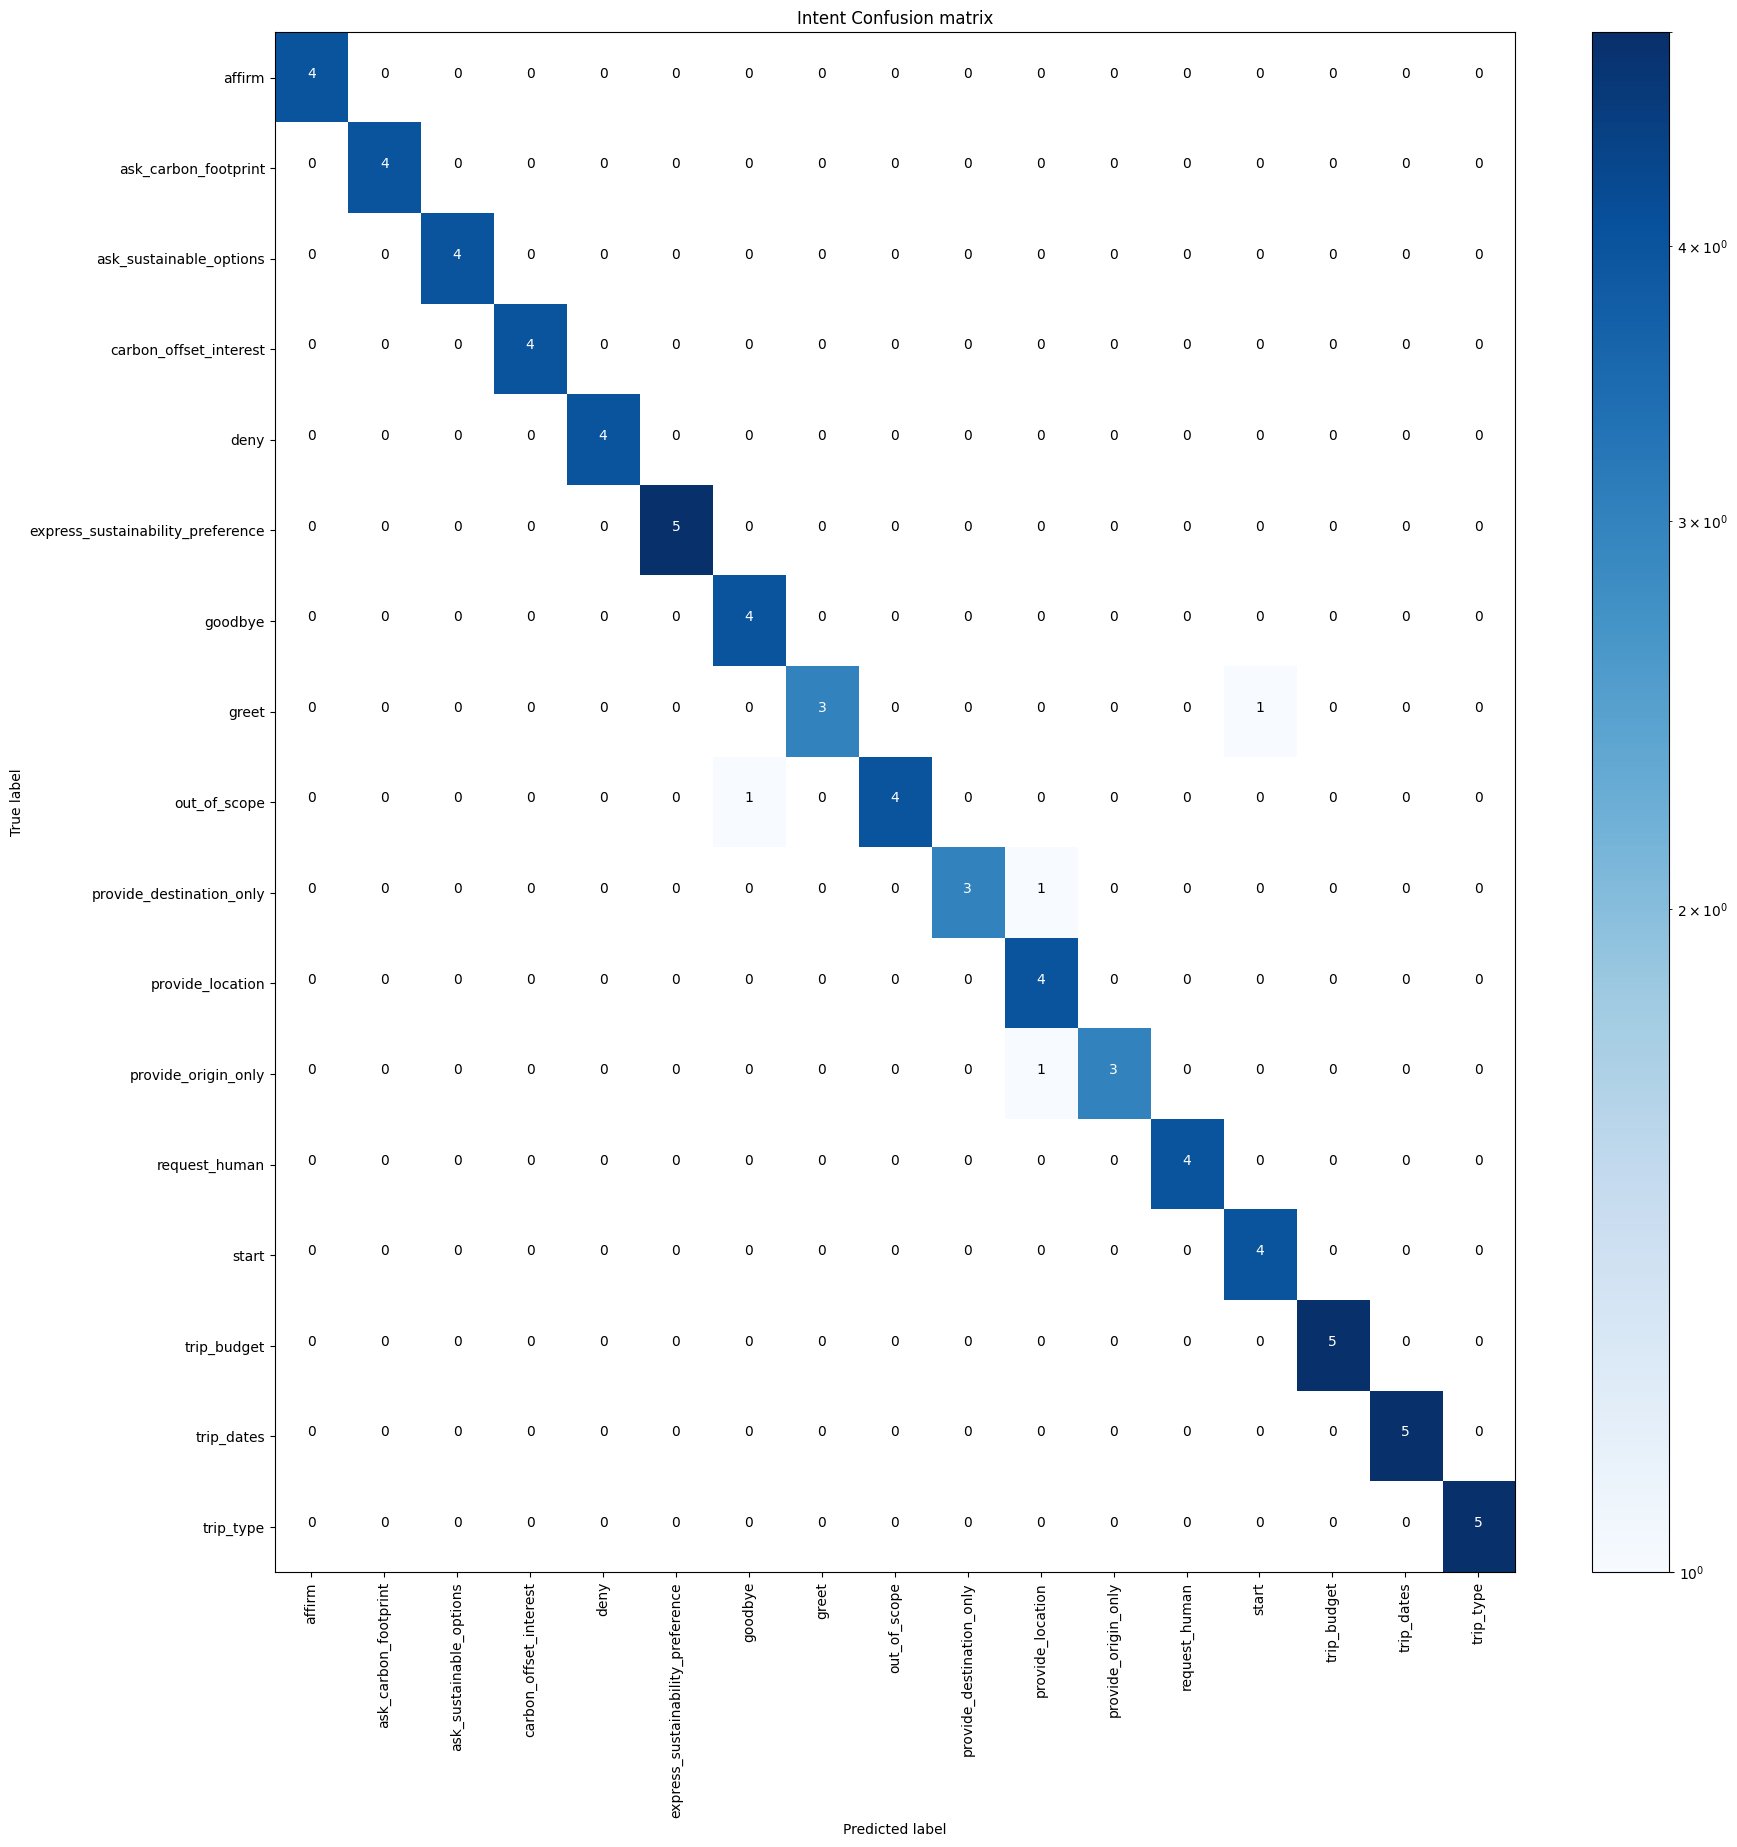

In [24]:
from IPython.display import Image
Image("results_nlu/intent_confusion_matrix.png")
#Image("/content/results/DIETClassifier_confusion_matrix.png")

In [6]:
!git clone https://huggingface.co/spaces/Zibraan/Eco_Travel_Advisor_Chatbot

Cloning into 'Eco_Travel_Advisor_Chatbot'...
fatal: could not read Username for 'https://huggingface.co': No such device or address


In [9]:
!git clone https://huggingface.co/spaces/Zibraan/Eco_Travel_Advisor_Chatbot

Cloning into 'Eco_Travel_Advisor_Chatbot'...
fatal: could not read Username for 'https://huggingface.co': No such device or address
